## Deconvoluting spatialATAC data with Cell2Location

In this tutorial, we go over how to run Cell2Location with deconvATAC.

### Import libraries

In [120]:
import sys
print(sys.executable)
import warnings
warnings.filterwarnings('ignore')
from deconvatac.tl import cell2location
from deconvatac.pp import highly_variable_peaks
import scanpy as sc
import pandas as pd
import numpy as np

/Users/rzhuang/Documents/PycharmProjects/deconvATAC/.venv/bin/python


### Read in the data

We will use the human melanoma dataset by [Russell et al.](https://doi.org/10.1038/s41586-023-06837-4). The data is available for download on [Zenodo](https://zenodo.org/records/15089738) in `example_notebooks.zip`. 

In [121]:
russell_st = sc.read_h5ad("./data/example_notebooks/cell2location/russell_250_atac.h5ad")
russell_st
#russell_st.obsm["spatial"]
#russell_st.obsm["proportions"].shape
#russell_st.obs.shape
#print(russell_st.obs)
#russell_st.var
#print(russell_st.X[:,10])
#russell_st.layers["tfidf_normalized"]
#russell_st.obsm["spatial"].shape # x,y coordinates
#russell_st.obsm["proportions"] # 250 x 10, 
#russell_st.uns["proportion_names"]  # cell type names



AnnData object with n_obs × n_vars = 360 × 53451
    obs: 'cell_count'
    var: 'features'
    uns: 'log1p', 'proportion_names'
    obsm: 'proportions', 'spatial'
    layers: 'log_norm', 'tfidf_normalized'

In [51]:
russell_sc = sc.read_h5ad("./data/example_notebooks/cell2location/russel_ref_atac.h5ad")
russell_sc

AnnData object with n_obs × n_vars = 2535 × 53451
    obs: 'barcodes', 'NAME_x', 'X', 'Y', 'cell_type', 'NAME_y', 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster'
    var: 'features'
    uns: 'cell_type_colors', 'log1p'
    obsm: 'X_umap', 'spatial'
    layers: 'log_norm', 'tfidf_normalized'

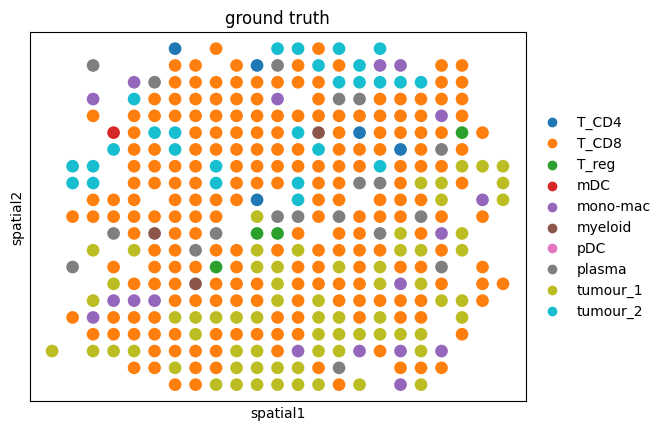

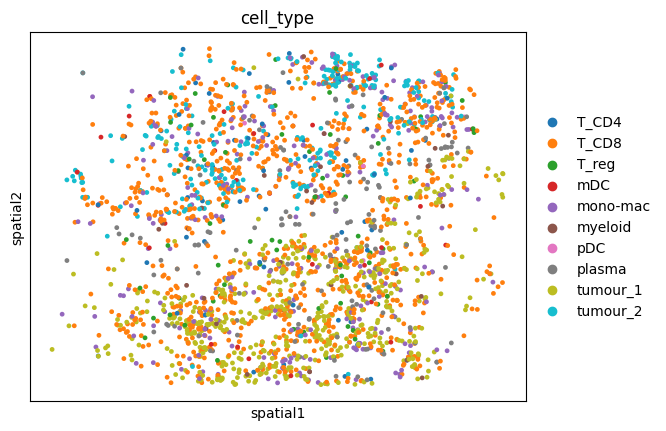

In [34]:
# Calculate the most probable cluster assignment
max_prob_cluster = np.argmax(russell_st.obsm["proportions"], axis=1)
# Get the column names
cluster_id = russell_st.uns["proportion_names"]
russell_st.obs["ground truth"] = cluster_id[max_prob_cluster]
russell_st.obs['ground truth'] = pd.Categorical(russell_st.obs['ground truth'], categories=russell_sc.obs.cell_type.cat.categories)
russell_st.uns["ground truth_colors"] = russell_sc.uns["cell_type_colors"].copy()
sc.pl.embedding(russell_st, basis = "spatial", color = "ground truth")
sc.pl.embedding(russell_sc, basis = "spatial", color = "cell_type")

### Select HVFs with deconvATAC

Before running deconvolution, the feature space should be subsetted onto a smaller space. Since the method of highly variable feature selection shows greater performance than the highly accessible feature approach, we will select features using the [deconvatac.pp.highly_variable_peaks](https://deconvatac.readthedocs.io/en/latest/autoapi/deconvatac/pp/feature_selection/index.html#deconvatac.pp.feature_selection.highly_variable_peaks) function. 

The [deconvatac.pp.highly_variable_peaks](https://deconvatac.readthedocs.io/en/latest/autoapi/deconvatac/pp/feature_selection/index.html#deconvatac.pp.feature_selection.highly_variable_peaks) function selects the highly variable features in place and saves the result to `.var["highly_variable"]`. It takes as input the key in `.obs` of the clusters by which the method identifies highly
variable peaks across. In our case, the `cluster_key` is the cell type.

In [35]:
highly_variable_peaks(adata=russell_sc, cluster_key="cell_type")

In [36]:
russell_st = russell_st[:, russell_sc.var["highly_variable"]]
russell_sc = russell_sc[:, russell_sc.var["highly_variable"]]

### Run Cell2Location

In [38]:
russell_st, russell_sc = cell2location(adata_spatial=russell_st, adata_ref=russell_sc, N_cells_per_location=8, detection_alpha=20
              , labels_key="cell_type", use_gpu=False, max_epochs_spatial=400, max_epochs_ref=400, return_adatas=True)

/Users/rzhuang/Documents/PycharmProjects/deconvATAC/.venv/lib/python3.11/site-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_resolver.py:193: DeprecationWarning: Use is_view instead of isview, isview will be removed in the future.
  attr = getattr(var, name)


KeyboardInterrupt: 

In the returned `AnnDatas`, we can find the posteriors of the spatial mapping and reference model: 

In [19]:
russell_st, russell_sc

(AnnData object with n_obs × n_vars = 360 × 20000
     obs: 'cell_count', 'leiden_pca', 'leiden_lsi', '_indices', '_scvi_batch', '_scvi_labels'
     var: 'features', 'highly_variable', 'highly_accessible'
     uns: 'leiden', 'log1p', 'lsi', 'neighbors', 'pca', 'proportion_names', '_scvi_uuid', '_scvi_manager_uuid', 'mod'
     obsm: 'X_lsi', 'X_pca', 'proportions', 'spatial', 'means_cell_abundance_w_sf', 'stds_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q95_cell_abundance_w_sf'
     varm: 'LSI', 'PCs'
     layers: 'log_norm', 'tfidf_normalized'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2535 × 20000
     obs: 'barcodes', 'NAME_x', 'X', 'Y', 'cell_type', 'NAME_y', 'biosample_id', 'donor_id', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex', 'cluster', '_indices', '_scvi_batch', '_scvi_labels'
     var

The resulting `means_cell_abundance_w_sf` and `q05_cell_abundance_w_sf` cell type abundances are also saved to directory `./cell2location_results`

#### Visualize results

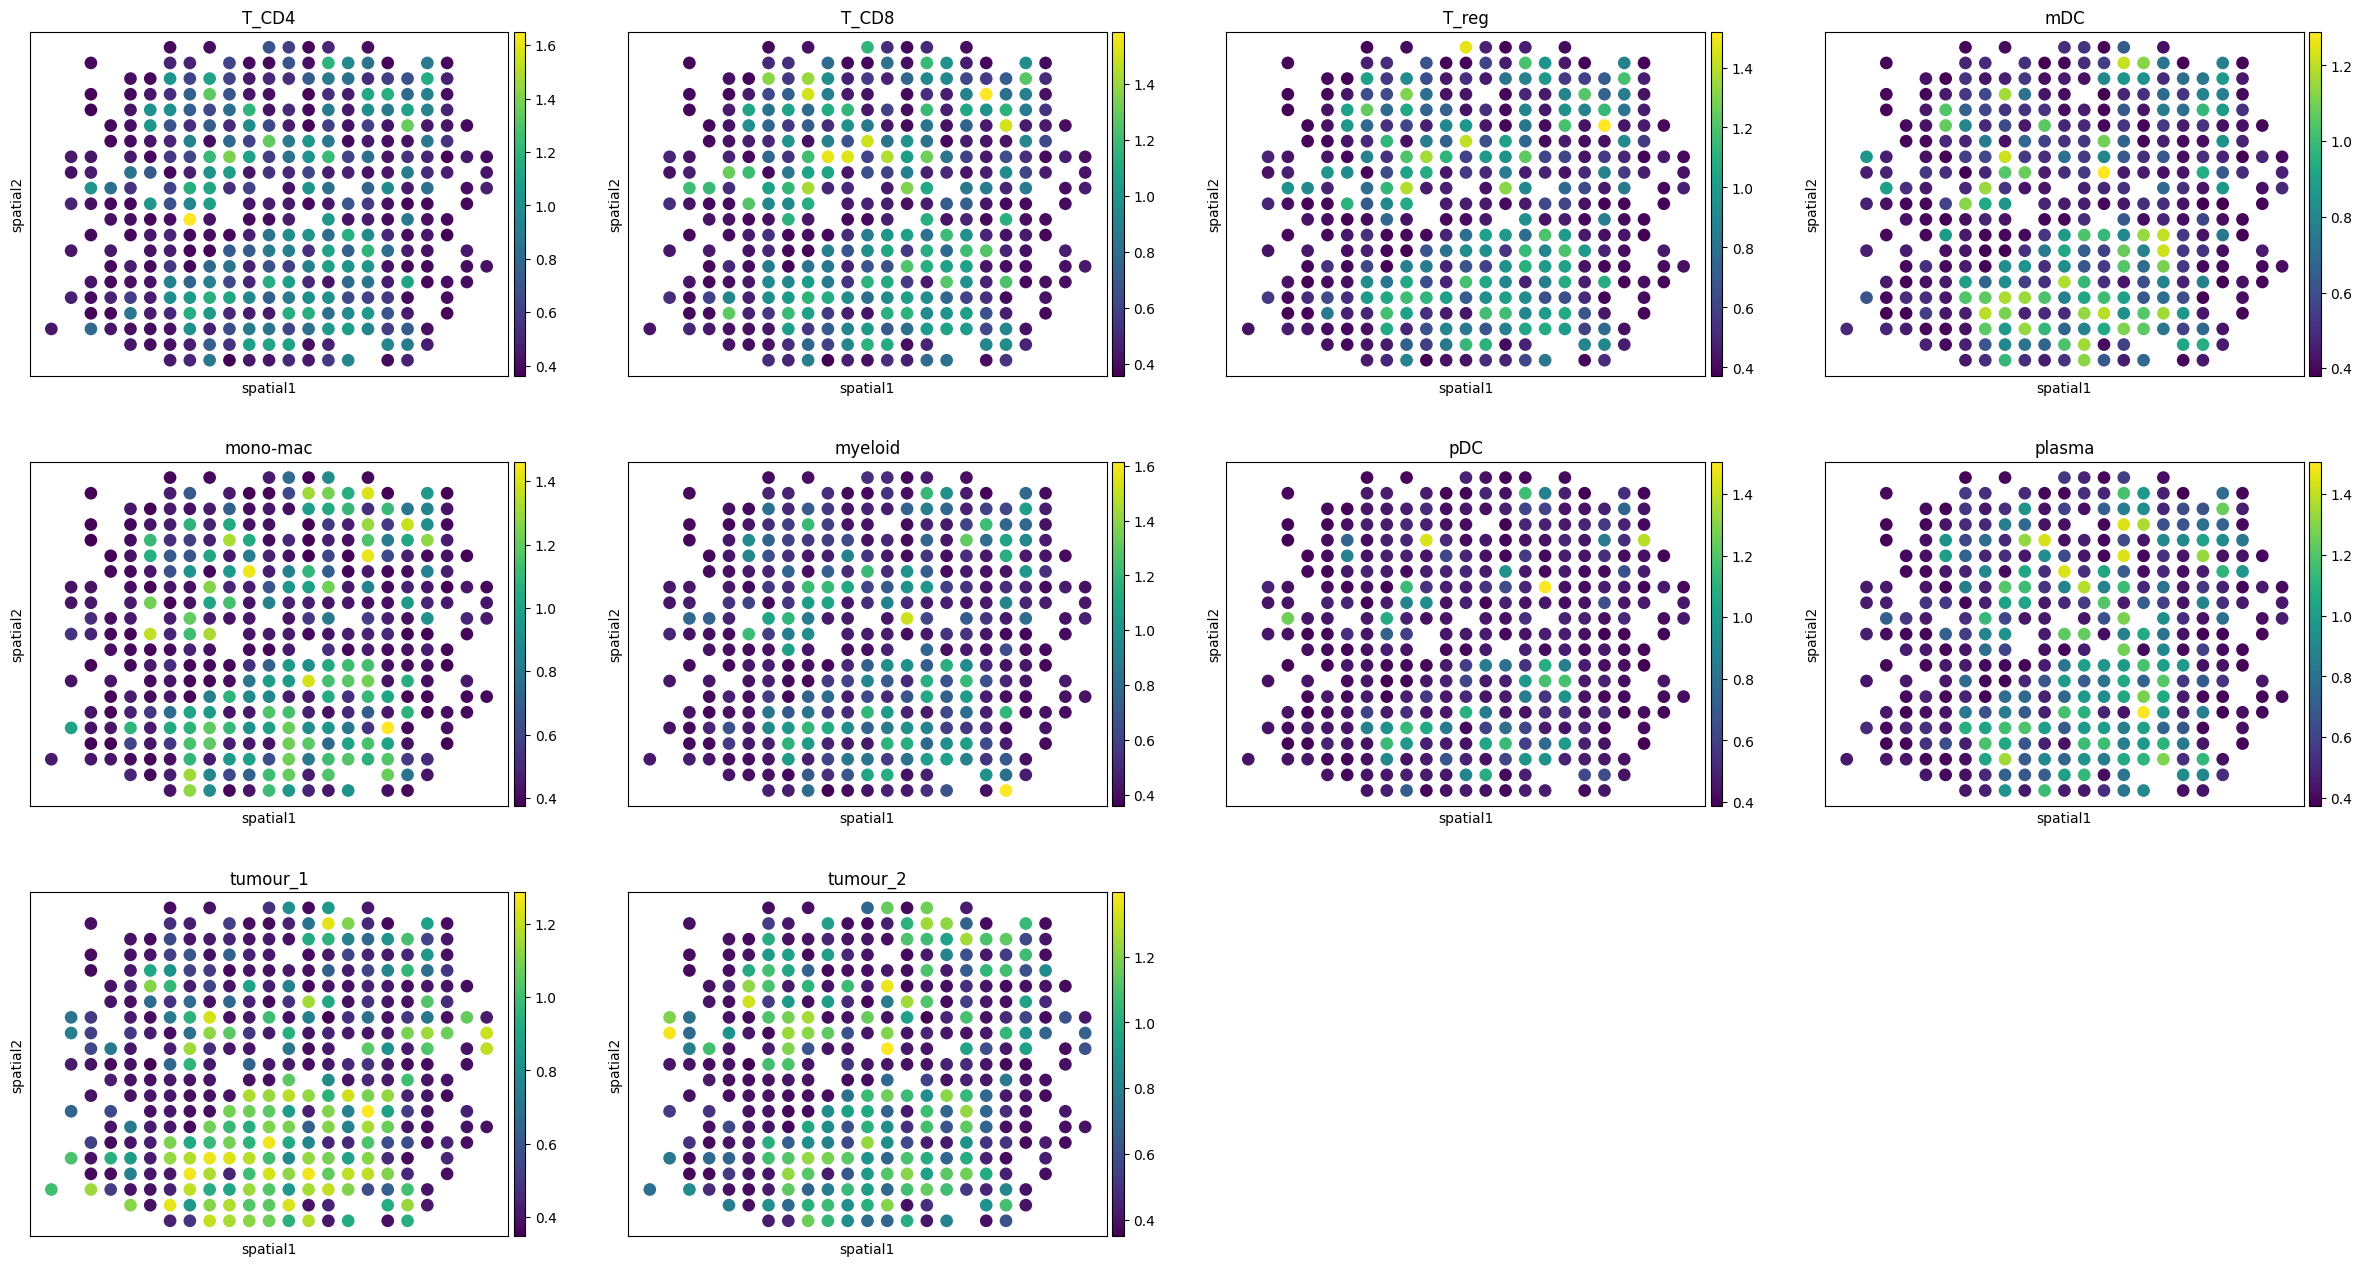

In [6]:
russell_st.obs[russell_st.uns["mod"]["factor_names"]] = russell_st.obsm["q05_cell_abundance_w_sf"]
sc.pl.embedding(russell_st,basis="spatial",color=russell_st.uns["mod"]["factor_names"]) 
